## 讀取影像 ------------------------------------------------------------------

In [1]:
from google.colab import drive

# 掛載 Google Drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [2]:
!pip install opencv-python

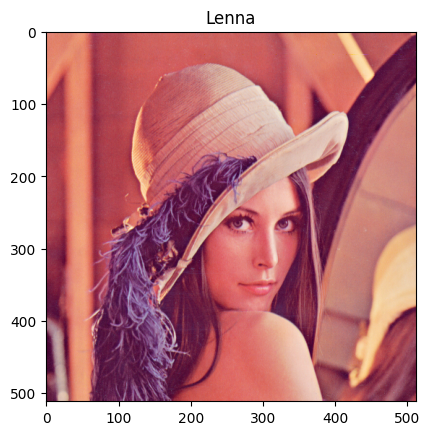

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1) 讀取圖片 (換成你要測試的檔案路徑)
img = cv2.imread("/content/drive/MyDrive/TKU_edu/影像處理/W2_數位影像基礎/Code_area/Lenna.png", cv2.IMREAD_UNCHANGED)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)#沒有轉換的話，讀取會是BGR
plt.title("Lenna")

plt.show()

## Part 1-1.最鄰近插值法

In [ ]:
def nearest_neighbor(image, target_width, target_height):
  # 1.獲取影像
  # height width是原本長寬， target是目標長寬
  if len(image.shape) == 3:
    orin_height, orin_width, channels = image.shape
    output_image = np.zeros((target_height, target_width, channels), dtype=np.uint8)
  else:
    orin_height, orin_width = image.shape
    output_image = np.zeros((target_height, target_width), dtype=np.uint8)

  #2.計算縮放比例
  scale_x = orin_width / target_width
  scale_y = orin_height / target_height

  # 插值時間
  # NumPy陣列的形狀是 (height, width) 或 (height, width, channels)
  for t_h in range(target_height):
    for t_w in range(target_width):

      #找到縮放後的點，對應回去原本的影像
      orin_x = int(t_w * scale_x)
      orin_y = int(t_h * scale_y)

      # 找到最鄰近的像素座標（四捨五入）
      nearest_x = int(round(orin_x))
      nearest_y = int(round(orin_y))

      nearest_x = min(max(nearest_x, 0), orin_width - 1)
      nearest_y = min(max(nearest_y, 0), orin_height - 1)

      if len(image.shape) == 3:
        output_image[t_h, t_w] = image[nearest_y, nearest_x]
      else:
        output_image[t_h, t_w] = image[nearest_y, nearest_x]

  return output_image

## Part 1-2雙線性插值法

In [ ]:
def bilinear_interpolation(image, target_width, target_height):
  #讀取圖片資訊
  if len(image.shape) == 3:
    orin_height, orin_width, channels = image.shape
    output_image = np.zeros((target_height, target_width, channels), dtype=np.uint8)
  else:
    orin_height, orin_width = image.shape
    output_image = np.zeros((target_height, target_width), dtype=np.uint8)
  ## 計算縮放比例
  x_scale = (orin_width - 1) / (target_width - 1) if target_width > 1 else 0
  y_scale = (orin_height - 1) / (target_height - 1) if target_height > 1 else 0

  for target_y in range(target_height):
    for target_x in range(target_width):
      #找到對應原始影像座標
      orin_x = target_x * x_scale
      orin_y = target_y * y_scale

      #找到周圍四個像素左標
      x1 = int(np.floor(orin_x))
      y1 = int(np.floor(orin_y))
      x2 = min(x1 + 1, orin_width - 1) #width-1是怕超過邊界上限值
      y2 = min(y1 + 1, orin_height - 1)

      #計算權重 水平和垂直
      wx = orin_x - x1
      wy = orin_y - y1

      #計算插值點
      # 1.彩色圖
      if len(image.shape) == 3:
        for c in range(channels):
          I11 = image[y1, x1, c] #左上
          I21 = image[y1, x2, c] #右上
          I12 = image[y2, x1, c] #左下
          I22 = image[y2, x2, c] #右下

          #執行插值(使用推導公式)
          interpolated_value = (I11 * (1 - wx) * (1 - wy) + I21 * wx * (1 - wy) + I12 * (1 - wx) * wy + I22 * wx * wy)
          output_image[target_y, target_x, c] = interpolated_value

      # 2.灰階圖
      else:
        I11 = image[y1, x1]
        I21 = image[y1, x2]
        I12 = image[y2, x1]
        I22 = image[y2, x2]

        interpolated_value = (I11 * (1 - wx) * (1 - wy) + I21 * wx * (1 - wy) + I12 * (1 - wx) * wy + I22 * wx * wy)
        output_image[target_y, target_x] = interpolated_value

  output_image = np.clip(output_image, 0, 255)
  return output_image.astype(image.dtype)

## 取樣(sampling)

In [ ]:
#使用interpolation(最鄰近內插)方法
def sampling(img, factor):
    h, w, c = img.shape
    trans_small = cv2.resize(img, (w // factor, h // factor), interpolation=cv2.INTER_NEAREST)
    sampled = cv2.resize(trans_small, (w, h), interpolation=cv2.INTER_NEAREST)
    return sampled

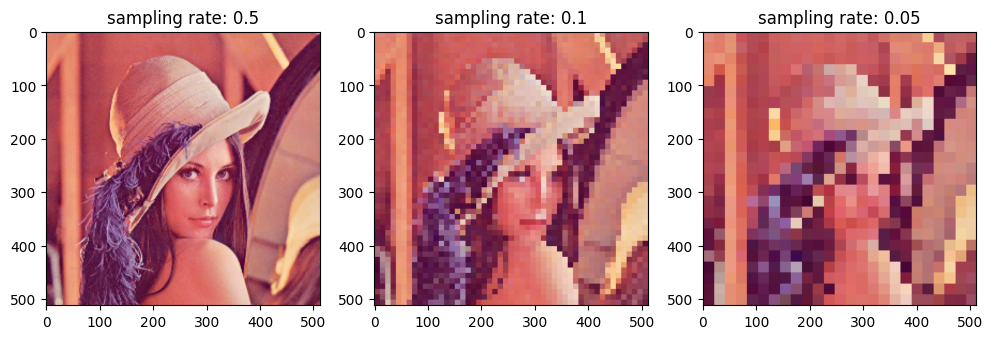

In [ ]:
plt.figure(figsize=(12, 4))
for i, f in enumerate([2, 10, 20]):
    plt.subplot(1, 3, i+1)
    plt.imshow(sampling(img, f))
    plt.title(f"sampling rate: {1/f}")
plt.show()

#plt.subplot(nrows, ncols, index)
#nrows → 總共有幾列（row）
#ncols → 總共有幾行（column）
#index → 目前要畫第幾張圖（從 1 開始數）

## 量化(Quantization)
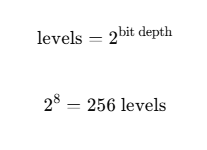


In [ ]:
def quantization(img, levels):
    # 計算每個量化區間的大小
    step = 256 // levels
    q_img = (img // step) * step
    return q_img.astype(np.uint8)

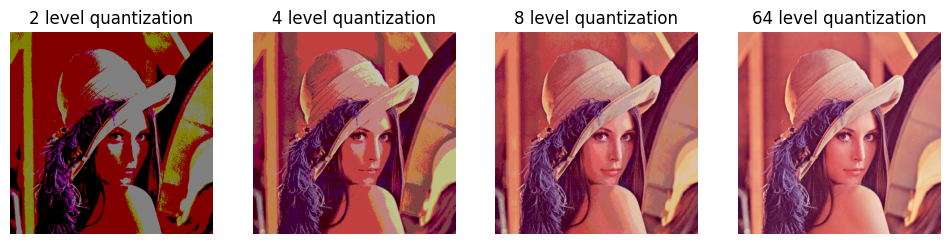

In [ ]:
plt.figure(figsize=(12,4))
for i, lv in enumerate([2, 4, 8, 64]):
    plt.subplot(1,4,i+1)
    plt.imshow(quantization(img, lv), cmap="gray", vmin=0, vmax=255)
    plt.title(f"{lv} level quantization")
    plt.axis("off")
plt.show()